In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Répertoires
pmf_dir = '../data/mono_data/popc-mono/pmfs/'
dist_dir = '../data/mono_data/popc-mono/distributions/'
output_dir = '../plot/'

# Constantes
k_B = 0.008314  # kJ/mol·K
T = 303.15
epsilon = 1e-5

In [ ]:
def free_energy(pKa, charge):
    """Calcule l'énergie libre de référence pour les formes neutres"""
    R = 8.314e-3  # kJ/mol.K
    T = 302.3545798089109  # K
    pH = 7.0
    return -charge * R * T * np.log(10) * (pKa - pH)


def get_ref_per_acid(acid):
    """
    Retourne la correction d'énergie libre pour la forme neutre.
    Source: Platzer et al. (2014)
    pKa: ARG 13.9, LYS 10.34, ASP 3.86, GLU 4.34, HIS 6.45, CYS 8.49, TYR 9.76
    """
    # Pour la ref aux résidus chargés
    neutrals = ['SCHE', 'SCHD', 'SCKN', 'SCRN', 'SCDN', 'SCEN', 'SCC', 'SCY']
    pKas = [6.45, 6.45, 10.34, 13.9, 3.86, 4.34, 8.49, 9.76]
    charges = [1, 1, 1, 1, -1, -1, -1, -1]
    
    if acid in neutrals:
        return free_energy(pKas[neutrals.index(acid)], charges[neutrals.index(acid)])
    return 0


def PMF_residue(acid):
    """
    Charge directement le fichier PMF pré-calculé.
    Colonnes attendues: x, PMF_mean, std_error
    """
    return pd.read_table(pmf_dir + f'{acid}.dat'.lower(), sep=r"\s+")


def find_zero_density_limit(acid):
    """
    Trouve la valeur |z| la plus haute où la densité est 0 dans les 3 trajectoires.
    
    Parcourt les fichiers trajectory*.dat et trouve le z (en absolu) maximal
    où la densité est nulle (0.0) et qui se répète dans les 3 trajectoires.
    
    Returns:
        float: la limite z en dessous de laquelle les données sont invalides (densité nulle)
    """
    acid_dir = os.path.join(dist_dir, acid.lower())
    file_list = sorted(glob.glob(os.path.join(acid_dir, "trajectory*.dat")))
    
    if len(file_list) == 0:
        print(f"Attention: aucun fichier distribution trouvé pour {acid}")
        return 0.0
    
    # Pour chaque trajectoire, trouver les z (en absolu) où densité = 0
    zero_z_sets = []
    for filename in file_list:
        #la première colonne ne doit pas être utilisée comme index lors de la génération du DataFrame
        df = pd.read_csv(filename, sep=r'\s+', header=None, names=["x", "y", "e"], dtype={'x': float, 'y': float, 'e': float})
        # Prendre les valeurs absolues de z
        df['x_abs'] = df['x'].abs()
        #display(df)
        # Trouver les z où densité = 0
        df_z1 = df[df['y'] == 0.0]
        df_z2 = df_z1[df_z1['x_abs'] < 20.0]  # Exclure les z trop éloignés (>20 Å)
        zeros = df_z2['x_abs'].values
        #print(zeros)
        zero_z_sets.append(set(zeros))
    # Intersection: z où densité = 0 dans TOUTES les trajectoires
    common_zeros = zero_z_sets[0]
    print(zero_z_sets)
    for zset in zero_z_sets[1:]:
        #common_zeros = common_zeros.intersection(zset)
        common_zeros = common_zeros.union(zset)
        #zéro présent sur au moins 1 trajectoire
    
    if len(common_zeros) == 0:
        return 0.0  # Pas de zéro commun
    
    # Retourner le z maximal (le plus éloigné de 0) où la densité est nulle
    return max(common_zeros) + 1


def get_interval_btw_PMF(ref_data, new_data, correction, z_limit_ref=0.0, z_limit_new=0.0):
    """
    Calcule la différence d'énergie libre ΔG = PMF_new - PMF_ref + correction
    et propage l'erreur: SE = sqrt(SE_ref² + SE_new²)
    
    Args:
        ref_data: DataFrame avec x, PMF_mean, std_error (forme neutre)
        new_data: DataFrame avec x, PMF_mean, std_error (forme chargée)
        correction: correction d'énergie libre
        z_limit_ref: limite z pour la forme de référence (points < z_limit sont exclus)
        z_limit_new: limite z pour la nouvelle forme (points < z_limit sont exclus)
    
    Returns:
        DataFrame avec x, DG_mean, DG_std_error
    """
    # Fusionner sur x
    merged = pd.merge(ref_data, new_data, on='x', suffixes=('_ref', '_new'))
    
    # Filtrer les points en dessous des limites de densité nulle
    z_limit = max(z_limit_ref, z_limit_new)
    if z_limit > 0:
        merged = merged[merged['x'] > z_limit].copy()
    
    # Calcul de ΔG
    merged['DG_mean'] = merged['PMF_mean_new'] - merged['PMF_mean_ref'] + correction
    
    # Propagation de l'erreur: sqrt(SE_ref² + SE_new²)
    merged['DG_std_error'] = np.sqrt(merged['std_error_ref']**2 + merged['std_error_new']**2)
    
    return merged[['x', 'DG_mean', 'DG_std_error']]

In [38]:
# Définition des acides aminés
aa_name = ['SCRN', 'SCR', 'SCKN', 'SCK', 'SCHE', 'SCHP',
           'SCDN', 'SCD', 'SCEN', 'SCE', 'SCC', 'SCCM', 'SCY', 'SCYM']

aa_symbol = ['ARGN', 'ARG', 'LYSN', 'LYS', 'HSE', 'HIS',
             'ASPN', 'ASP', 'GLUN', 'GLU', 'CYSN', 'CYS', 'TYRN', 'TYR']

aa_charge = [0, 1, 0, 1, 0, 1, 0, -1, 0, -1, 0, -1, 0, -1]


def pKa_func(DG, charge):
    """Convertit une différence d'énergie libre en pKa"""
    R = 8.314e-3  # kJ/mol.K
    T = 302.3545798089109  # K
    pH = 7.0
    return -DG / (charge * R * T * np.log(10)) + pH


def compute_pKa_dataframe(filter_plateau=False):
    """
    Calcule les pKa pour tous les acides aminés à partir des fichiers PMF pré-calculés.
    
    Args:
        filter_plateau: Si True, retire les points où la densité est nulle
                        (déterminé depuis les fichiers de distribution)
    
    Returns:
        DataFrame avec x, pKa et std pour chaque acide aminé
    """
    results_list = []
    
    for i in range(0, len(aa_name), 2):
        # Charger les PMF pré-calculés
        ref_data = PMF_residue(aa_name[i])      # Forme neutre
        new_data = PMF_residue(aa_name[i + 1])  # Forme chargée
        
        acid_s = aa_symbol[i + 1]
        charge = aa_charge[i + 1]
        correction = get_ref_per_acid(aa_name[i])
        
        # Trouver les limites z où la densité devient nulle
        if filter_plateau:
            z_limit_ref = find_zero_density_limit(aa_name[i])
            z_limit_new = find_zero_density_limit(aa_name[i + 1])
        else:
            z_limit_ref = 0.0
            z_limit_new = 0.0
        
        # Calcul de ΔG avec propagation d'erreur
        DG = get_interval_btw_PMF(ref_data, new_data, correction, 
                                   z_limit_ref=z_limit_ref, z_limit_new=z_limit_new)
        
        # Conversion en pKa
        DG['pKa'] = pKa_func(DG['DG_mean'], charge)
        # Propagation de l'erreur pour pKa: |dpKa/dDG| * SE_DG
        R = 8.314e-3
        T = 302.3545798089109
        DG['pKa_std'] = np.abs(1 / (charge * R * T * np.log(10))) * DG['DG_std_error']
        
        # Renommer les colonnes pour cet acide
        DG_renamed = DG[['x', 'pKa', 'pKa_std']].rename(columns={
            'pKa': f'pKa_{acid_s}',
            'pKa_std': f'std_{acid_s}'
        })
        results_list.append(DG_renamed)
    
    # Fusionner tous les résultats sur x
    result = results_list[0]
    for df in results_list[1:]:
        result = pd.merge(result, df, on='x', how='outer')
    
    return result.sort_values('x').reset_index(drop=True)


# Calcul des deux DataFrames
print("Calcul des pKa (tous points)...")
df_e = compute_pKa_dataframe(filter_plateau=False)  # Tous les points (avec plateau)

print("Calcul des pKa (sans plateau - basé sur densité nulle)...")
df_0 = compute_pKa_dataframe(filter_plateau=True)   # Sans les points au plateau

# Affichage des limites trouvées
print("\n=== Limites de densité nulle trouvées ===")
for i in range(0, len(aa_name), 2):
    z_ref = find_zero_density_limit(aa_name[i])
    z_new = find_zero_density_limit(aa_name[i + 1])
    print(f"{aa_symbol[i+1]}: ref ({aa_name[i]}) z_min={z_ref:.1f} Å, new ({aa_name[i+1]}) z_min={z_new:.1f} Å")

print("\n=== Résumé des calculs ===")
print("PMF chargés depuis fichiers .dat pré-calculés")
print("Erreur standard: sqrt(SE_ref² + SE_new²)")

print("\nExtrait pour z ∈ [0, 17] Å (tous points):")
display(df_e[(df_e['x'] > 0) & (df_e['x'] < 17)])

print("\nExtrait pour z ∈ [0, 17] Å (sans plateau):")
display(df_0[(df_0['x'] > 0) & (df_0['x'] < 17)])

Calcul des pKa (tous points)...
Calcul des pKa (sans plateau - basé sur densité nulle)...
[set(), set(), set()]
[{np.float64(0.5), np.float64(1.5), np.float64(2.5)}, {np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5)}, {np.float64(0.5), np.float64(1.5), np.float64(2.5)}]
[set(), set(), set()]
[{np.float64(0.5), np.float64(1.5)}, {np.float64(0.5)}, {np.float64(0.5), np.float64(1.5), np.float64(2.5)}]
[{np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5)}, {np.float64(1.5), np.float64(2.5), np.float64(3.5)}, {np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5)}]
[{np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5), np.float64(5.5), np.float64(6.5)}, {np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5), np.float64(5.5)}, {np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5), np.float64(5.5), np.float64(6.5)}]
[set(), set(), set()]


,x,pKa_ARG,std_ARG,pKa_LYS,std_LYS,pKa_HIS,std_HIS,pKa_ASP,std_ASP,pKa_GLU,std_GLU,pKa_CYS,std_CYS,pKa_TYR,std_TYR
0,0.5,13.366448,0.099633,7.402576,0.012313,6.414518,0.007764,4.890739,0.072975,6.071671,0.096582,12.829516,0.054248,13.050176,0.104713
1,1.5,13.146546,0.077400,7.410287,0.017326,6.410307,0.010221,4.854811,0.057518,6.126942,0.118601,12.818300,0.058711,13.139152,0.085197
2,2.5,12.744101,0.066408,7.453793,0.035648,6.399840,0.015792,4.869475,0.053668,6.283019,0.147740,12.796607,0.057703,13.305040,0.066302
3,3.5,12.309807,0.046469,7.620031,0.102456,6.345317,0.041230,5.105583,0.034856,6.526387,0.124482,12.764897,0.059033,13.585083,0.060726
4,4.5,11.975261,0.048768,7.849516,0.166752,6.253311,0.085157,5.504764,0.041913,6.812730,0.074773,12.729106,0.060744,13.911938,0.062794
5,5.5,11.956764,0.061282,8.179005,0.129986,6.108471,0.107060,5.932676,0.055642,7.121386,0.039428,12.689087,0.060290,14.225383,0.068236
6,6.5,12.129123,0.049400,8.531803,0.069165,5.828981,0.044135,6.318039,0.043932,7.409068,0.032831,12.672878,0.059261,14.423044,0.082210
7,7.5,12.345444,0.036479,8.881436,0.058035,5.476203,0.014346,6.670023,0.047792,7.681922,0.033260,12.696396,0.060244,14.592232,0.090386
8,8.5,12.549941,0.035178,9.167135,0.048283,5.184628,0.037913,6.964512,0.034571,7.911780,0.025807,12.747119,0.060823,14.464837,0.118323
9,9.5,12.744680,0.036134,9.392807,0.034279,5.201183,0.084115,7.202902,0.030734,8.104307,0.021382,12.820429,0.060219,14.260920,0.123901



Extrait pour z ∈ [0, 17] Å (sans plateau):


,x,pKa_ARG,std_ARG,pKa_LYS,std_LYS,pKa_HIS,std_HIS,pKa_ASP,std_ASP,pKa_GLU,std_GLU,pKa_CYS,std_CYS,pKa_TYR,std_TYR
0,3.5,NaN,NaN,7.620031,0.102456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.5,11.975261,0.048768,7.849516,0.166752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.5,11.956764,0.061282,8.179005,0.129986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.5,12.129123,0.049400,8.531803,0.069165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.5,12.345444,0.036479,8.881436,0.058035,5.476203,0.014346,NaN,NaN,NaN,NaN,NaN,NaN,14.592232,0.090386
5,8.5,12.549941,0.035178,9.167135,0.048283,5.184628,0.037913,NaN,NaN,NaN,NaN,NaN,NaN,14.464837,0.118323
6,9.5,12.744680,0.036134,9.392807,0.034279,5.201183,0.084115,NaN,NaN,NaN,NaN,NaN,NaN,14.260920,0.123901
7,10.5,12.925627,0.039974,9.578137,0.027950,5.371969,0.096947,NaN,NaN,NaN,NaN,NaN,NaN,13.956852,0.087453
8,11.5,13.097316,0.042165,9.748104,0.029387,5.583302,0.087173,NaN,NaN,8.211237,0.038869,12.899474,0.059957,13.600106,0.088660
9,12.5,13.255336,0.044713,9.895368,0.024776,5.820968,0.087434,7.424944,0.102236,8.053268,0.068170,12.756508,0.115336,13.293269,0.074098


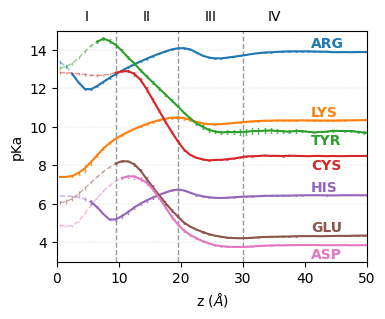

In [21]:
# Plot des pKa
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.figure(figsize=(4, 3))
list_aa = ['ARG', 'LYS', 'TYR', 'CYS', 'HIS', 'GLU', 'ASP']

for i, name in enumerate(list_aa):
    # Données sans plateau (ligne pleine)
    mask_0 = df_0['x'].notna() & df_0[f'pKa_{name}'].notna()
    x1 = df_0.loc[mask_0, 'x']
    y1 = df_0.loc[mask_0, f'pKa_{name}']
    e1 = df_0.loc[mask_0, f'std_{name}']
    
    # Données avec plateau (ligne pointillée)
    mask_e = df_e['x'].notna() & df_e[f'pKa_{name}'].notna()
    x2 = df_e.loc[mask_e, 'x']
    y2 = df_e.loc[mask_e, f'pKa_{name}']
    e2 = df_e.loc[mask_e, f'std_{name}']
    
    plt.errorbar(x1, y1, e1, linewidth=1.5, color=color[i], elinewidth=0.4, capthick=0.4, capsize=1)
    plt.errorbar(x2, y2, e2, linewidth=1, color=color[i], linestyle='dashed', alpha=0.5)
    
    # Label à droite
    if len(y1) > 0:
        # Trouver la valeur à z ≈ 40 Å pour positionner le texte
        idx_40 = (x1 - 40).abs().idxmin() if len(x1) > 0 else None
        if idx_40 is not None and idx_40 in y1.index:
            y_pos = y1.loc[idx_40]
            if name not in ['ASP', 'TYR', 'CYS']:
                plt.text(41, y_pos + 0.2, name, weight="bold", color=color[i])
            else:
                plt.text(41, y_pos - 0.7, name, weight="bold", color=color[i])

# Grille verticale personnalisée (lignes à 9.5, 19.5, 30) - en dehors de la boucle
custom_vgrid = [9.5, 19.5, 30]
for xv in custom_vgrid:
    plt.axvline(x=xv, linestyle='--', alpha=0.8, linewidth=1, color='gray', zorder=0)

# Grille horizontale
plt.gca().yaxis.grid(True, which='major', linestyle='--', alpha=0.5, linewidth=0.3)

# Chiffres romains en haut pour les zones membranaires
roman_numerals = [('I', 4.75), ('II', 14.5), ('III', 24.75), ('IV', 35)]
for numeral, x_pos in roman_numerals:
    plt.text(x_pos, 1.03, numeral, transform=plt.gca().get_xaxis_transform(),
             ha='center', va='bottom', fontsize=10, fontweight='normal')

plt.xlim([0, 50])
plt.ylim([3, 15])
plt.xlabel('z ($\AA$)')
plt.ylabel('pKa')
plt.savefig(output_dir + 'pKa.png', bbox_inches='tight', transparent=True, dpi=800)
plt.show()

In [17]:
# Calcul du ΔG sans shift à 0 dans l'eau
# On part directement des distributions pour calculer les PMF bruts

def load_distributions(acid):
    """
    Charge les fichiers de distribution et calcule la moyenne.
    
    Returns:
        DataFrame avec x, density_mean, density_std
    """
    acid_dir = os.path.join(dist_dir, acid.lower())
    file_list = sorted(glob.glob(os.path.join(acid_dir, "trajectory*.dat")))
    
    if len(file_list) == 0:
        print(f"Attention: aucun fichier distribution trouvé pour {acid}")
        return None
    
    dfs = []
    for filename in file_list:
        df = pd.read_csv(filename, sep=r'\s+', header=None, 
                         names=["x", "density", "e"], 
                         dtype={'x': float, 'density': float, 'e': float})
        dfs.append(df)
    
    # Fusionner sur x et calculer la moyenne
    merged = dfs[0][['x']].copy()
    for i, df in enumerate(dfs):
        merged = pd.merge(merged, df[['x', 'density']], on='x', how='outer', suffixes=('', f'_{i}'))
    
    # Colonnes de densité
    density_cols = [c for c in merged.columns if c.startswith('density')]
    merged['density_mean'] = merged[density_cols].mean(axis=1)
    merged['density_std'] = merged[density_cols].std(axis=1)
    
    return merged[['x', 'density_mean', 'density_std']].sort_values('x').reset_index(drop=True)


def compute_raw_PMF(acid):
    """
    Calcule le PMF brut (sans shift) depuis les distributions.
    PMF = -k_B * T * ln(density + epsilon)
    """
    dist = load_distributions(acid)
    if dist is None:
        return None
    
    dist['PMF_raw'] = -k_B * T * np.log(dist['density_mean'] + epsilon)
    return dist[['x', 'PMF_raw', 'density_mean']]


def compute_DeltaG_no_shift(neutral_acid, charged_acid, pKa_exp, charge):
    """
    Calcule ΔG entre les deux formes sans shift à 0 dans l'eau.
    
    Args:
        neutral_acid: nom de la forme neutre (ex: 'SCRN')
        charged_acid: nom de la forme chargée (ex: 'SCR')
        pKa_exp: pKa expérimental
        charge: charge de la forme chargée (+1 ou -1)
    
    Returns:
        dict avec les résultats
    """
    # Charger les PMF bruts
    pmf_neutral = compute_raw_PMF(neutral_acid)
    pmf_charged = compute_raw_PMF(charged_acid)
    
    if pmf_neutral is None or pmf_charged is None:
        return None
    
    # Fusionner
    merged = pd.merge(pmf_neutral, pmf_charged, on='x', suffixes=('_neutral', '_charged'))
    
    # Correction d'énergie libre pour la forme neutre
    correction = get_ref_per_acid(neutral_acid)
    
    # ΔG = PMF_charged - PMF_neutral + correction
    merged['DG'] = merged['PMF_raw_charged'] - merged['PMF_raw_neutral'] + correction
    
    # Trouver la valeur à z ≈ 45 Å (zone aqueuse)
    idx_45 = (merged['x'] - 45).abs().idxmin()
    DG_45 = merged.loc[idx_45, 'DG']
    z_45 = merged.loc[idx_45, 'x']
    
    # pKa calculé à partir de ΔG à 45 Å
    R = 8.314e-3  # kJ/mol.K
    pH = 7.0
    pKa_calc = -DG_45 / (charge * R * T * np.log(10)) + pH
    
    # ΔG correspondant au pKa expérimental
    DG_exp = -charge * R * T * np.log(10) * (pKa_exp - pH)
    
    return {
        'neutral': neutral_acid,
        'charged': charged_acid,
        'z': z_45,
        'DG_45': DG_45,
        'pKa_calc': pKa_calc,
        'pKa_exp': pKa_exp,
        'DG_exp': DG_exp,
        'correction': correction,
        'data': merged
    }


# Définition des paires acide/base et pKa expérimentaux
# Source: Platzer et al. (2014)
pairs = [
    ('SCRN', 'SCR', 'ARG', 13.9, 1),    # Arginine
    ('SCKN', 'SCK', 'LYS', 10.34, 1),   # Lysine
    ('SCHE', 'SCHP', 'HIS', 6.45, 1),   # Histidine
    ('SCDN', 'SCD', 'ASP', 3.86, -1),   # Aspartate
    ('SCEN', 'SCE', 'GLU', 4.34, -1),   # Glutamate
    ('SCC', 'SCCM', 'CYS', 8.49, -1),   # Cysteine
    ('SCY', 'SCYM', 'TYR', 9.76, -1),   # Tyrosine
]

print("=" * 80)
print("Calcul du ΔG sans shift à 0 dans l'eau")
print("PMF brut = -k_B * T * ln(density + ε)")
print("=" * 80)
print(f"\nConstantes: k_B = {k_B} kJ/mol·K, T = {T} K, ε = {epsilon}")
print(f"Correction = énergie libre de référence pour la forme neutre à pH 7")
print()

results = []
for neutral, charged, name, pKa_exp, charge in pairs:
    result = compute_DeltaG_no_shift(neutral, charged, pKa_exp, charge)
    if result:
        results.append(result)
        print(f"--- {name} ({neutral} ↔ {charged}) ---")
        print(f"  Correction énergie libre: {result['correction']:.2f} kJ/mol")
        print(f"  ΔG à z = {result['z']:.1f} Å: {result['DG_45']:.2f} kJ/mol")
        print(f"  pKa calculé: {result['pKa_calc']:.2f}")
        print(f"  pKa expérimental: {result['pKa_exp']:.2f}")
        print(f"  ΔG pour pKa exp: {result['DG_exp']:.2f} kJ/mol")
        print(f"  Écart pKa: {abs(result['pKa_calc'] - result['pKa_exp']):.2f}")
        print()

# Résumé en tableau
print("\n" + "=" * 80)
print("RÉSUMÉ")
print("=" * 80)
summary_df = pd.DataFrame([{
    'AA': pairs[i][2],
    'ΔG (45 Å)': f"{r['DG_45']:.2f}",
    'pKa calc': f"{r['pKa_calc']:.2f}",
    'pKa exp': f"{r['pKa_exp']:.2f}",
    'ΔG (pKa exp)': f"{r['DG_exp']:.2f}",
    '|Δ pKa|': f"{abs(r['pKa_calc'] - r['pKa_exp']):.2f}"
} for i, r in enumerate(results)])
display(summary_df)

Calcul du ΔG sans shift à 0 dans l'eau
PMF brut = -k_B * T * ln(density + ε)

Constantes: k_B = 0.008314 kJ/mol·K, T = 303.15 K, ε = 1e-05
Correction = énergie libre de référence pour la forme neutre à pH 7

--- ARG (SCRN ↔ SCR) ---
  Correction énergie libre: -39.94 kJ/mol
  ΔG à z = 44.5 Å: -41.16 kJ/mol
  pKa calculé: 14.09
  pKa expérimental: 13.90
  ΔG pour pKa exp: -40.04 kJ/mol
  Écart pKa: 0.19

--- LYS (SCKN ↔ SCK) ---
  Correction énergie libre: -19.33 kJ/mol
  ΔG à z = 44.5 Å: -20.21 kJ/mol
  pKa calculé: 10.48
  pKa expérimental: 10.34
  ΔG pour pKa exp: -19.38 kJ/mol
  Écart pKa: 0.14

--- HIS (SCHE ↔ SCHP) ---
  Correction énergie libre: 3.18 kJ/mol
  ΔG à z = 44.5 Å: 2.78 kJ/mol
  pKa calculé: 6.52
  pKa expérimental: 6.45
  ΔG pour pKa exp: 3.19 kJ/mol
  Écart pKa: 0.07

--- ASP (SCDN ↔ SCD) ---
  Correction énergie libre: -18.17 kJ/mol
  ΔG à z = 44.5 Å: -19.18 kJ/mol
  pKa calculé: 3.70
  pKa expérimental: 3.86
  ΔG pour pKa exp: -18.22 kJ/mol
  Écart pKa: 0.16

--- G

,AA,ΔG (45 Å),pKa calc,pKa exp,ΔG (pKa exp),|Δ pKa|
0,ARG,-41.16,14.09,13.90,-40.04,0.19
1,LYS,-20.21,10.48,10.34,-19.38,0.14
2,HIS,2.78,6.52,6.45,3.19,0.07
3,ASP,-19.18,3.70,3.86,-18.22,0.16
4,GLU,-17.03,4.07,4.34,-15.44,0.27
5,CYS,4.49,7.77,8.49,8.65,0.72
6,TYR,8.23,8.42,9.76,16.02,1.34
